# Estudio de convergencia de malla (GCI) — formato CODA_SINGLE

Cada raiz `GCI/aoa_*_m_*` es una base FRODO independiente con una condicion de vuelo
fija y **una malla distinta por caso** (`f0.8` … `f10`, donde el nombre es el factor de
refinamiento: menor factor = malla mas fina).

Este notebook recorre el pipeline entero del formato: lectura, residuos, integrales de
pared, algebra de variables por caso, reduccion entre mallas y GCI de Richardson.

In [2]:
try:
    import pyLOM
    print('Environment with pylom instaled')
except ImportError:
    import sys
    sys.path.append('/home/m.jaraiz/repos/pyLowOrder/')
from FotR import FRODO, SAM


0 Warning! Import - NVTX not present!


## 1. Convergencia del solver y monitores de pared

aoa_0.022_m_1.071: 8 casos -> ['f0.8', 'f0.9', 'f1', 'f1.5', 'f2', 'f3', 'f6', 'f10']


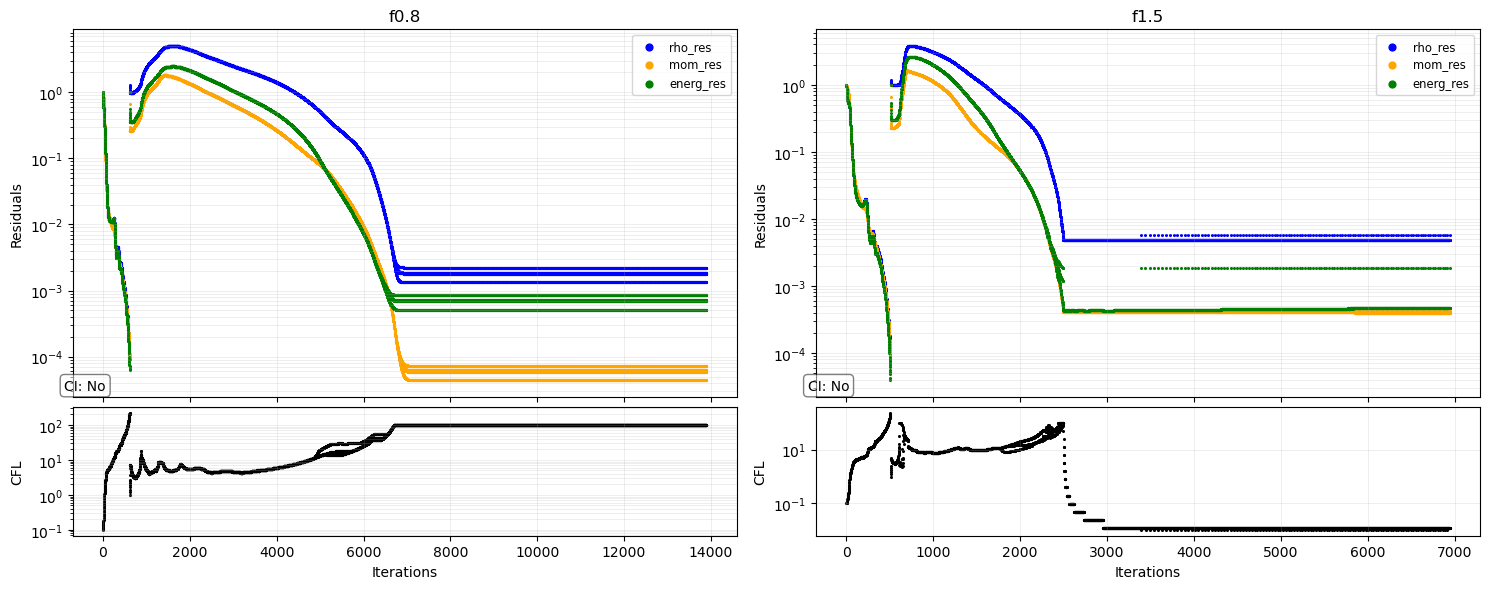

aoa_0.022_m_1.386: 8 casos -> ['f0.8', 'f0.9', 'f1', 'f1.5', 'f2', 'f3', 'f6', 'f10']


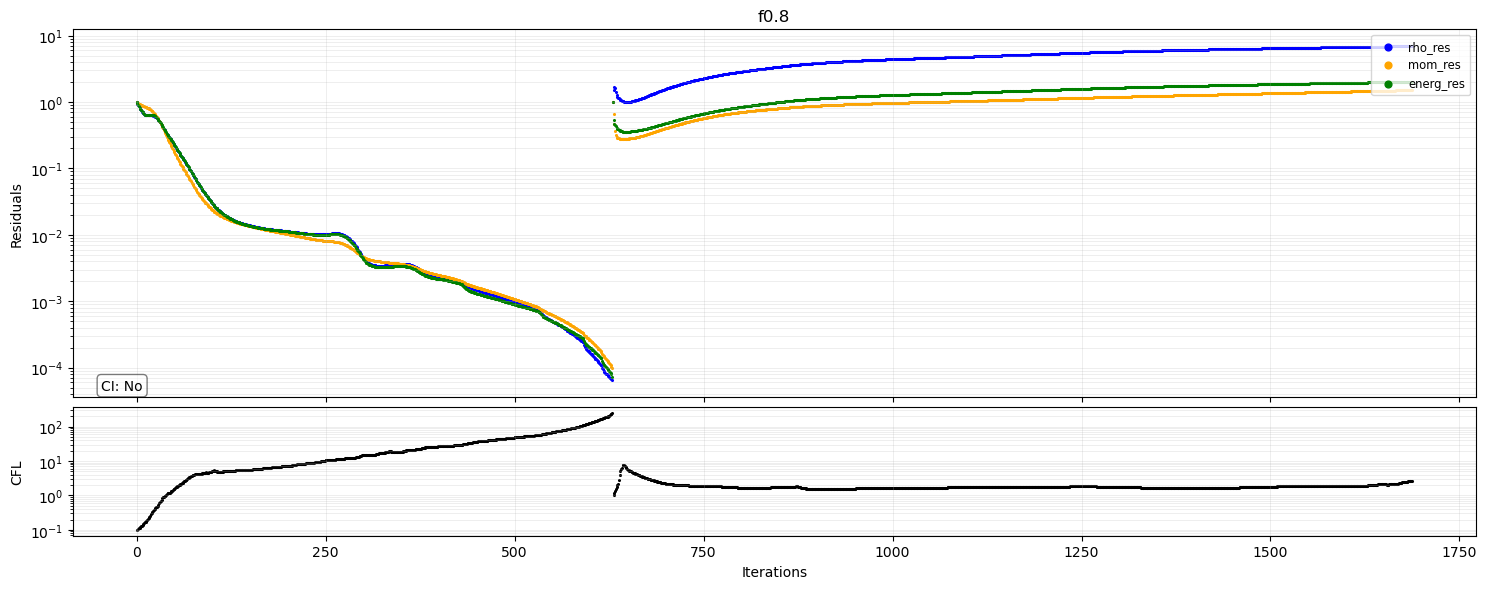

aoa_3.303_m_0.541: 8 casos -> ['f0.8', 'f0.9', 'f1', 'f1.5', 'f2', 'f3', 'f6', 'f10']


/home/m.jaraiz/repos/fellowship-of-the-ring/FotR/characters/residuals/coda.py:1220: UserWarning: No data found for the specified criteria.
  warnings.warn(


In [9]:
import os

GCI_DIR = '/home/m.jaraiz/Documentos/DATASETS/data_TIFON/GCI'
folders = sorted(f for f in os.listdir(GCI_DIR) if f.startswith('aoa'))

databases = {}
for folder in folders:
    db = FRODO(os.path.join(GCI_DIR, folder), format="CODA_SINGLE",
               initial_parse=True)
    databases[folder] = db
    print(f"{folder}: {len(db.reader.sim_metadata)} casos ->",
          db.df_state['folder'].tolist())
    
    db.residuals.plot_state_calculation(
        num_stages = 1,
        txt_from_end = 1
    )

# Ultima base cargada, para las celdas de inspeccion rapida de mas abajo.
db = databases[folders[-1]]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.8, 0.9, 1.0, 1.5, 2.0, 3.0, 6.0, 10.0])

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.scatter(
    x = x,
    y = np.floor(6500/x**0.8),
)
ax.set_xlabel('f')
ax.set_ylabel('Airfoil elements')

aoa_0.022_m_1.071


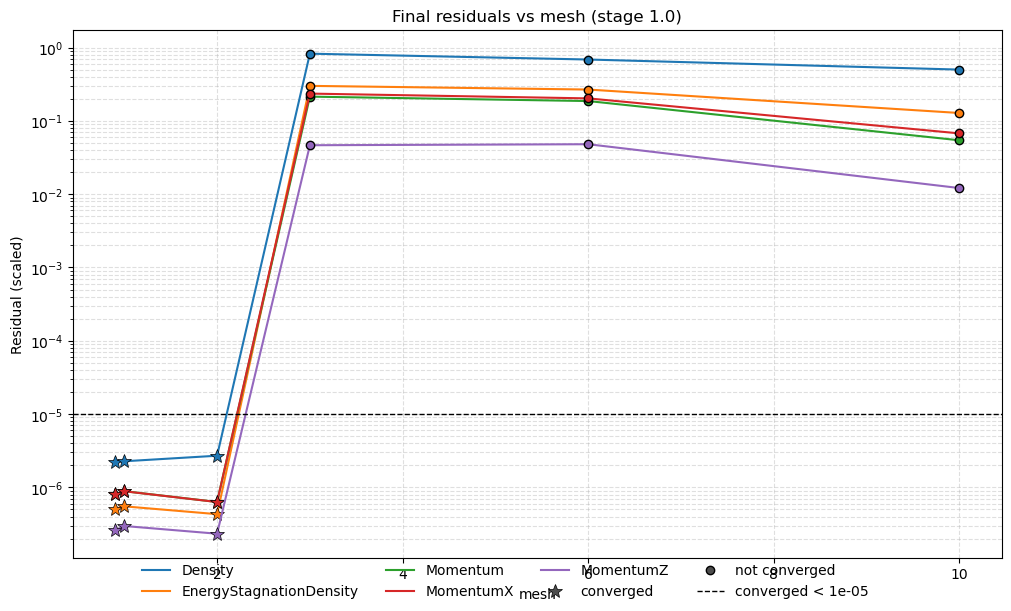

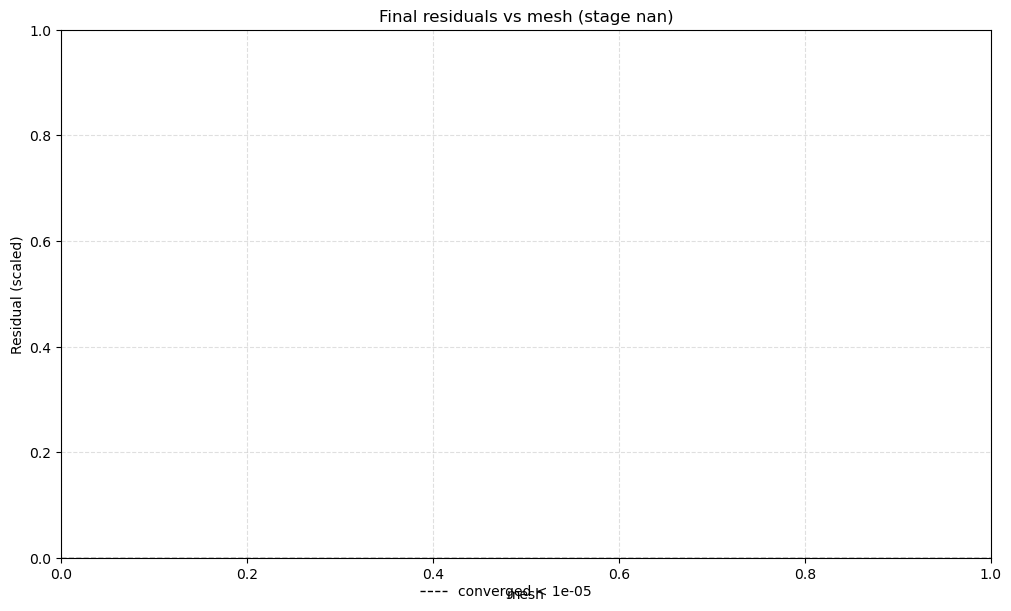

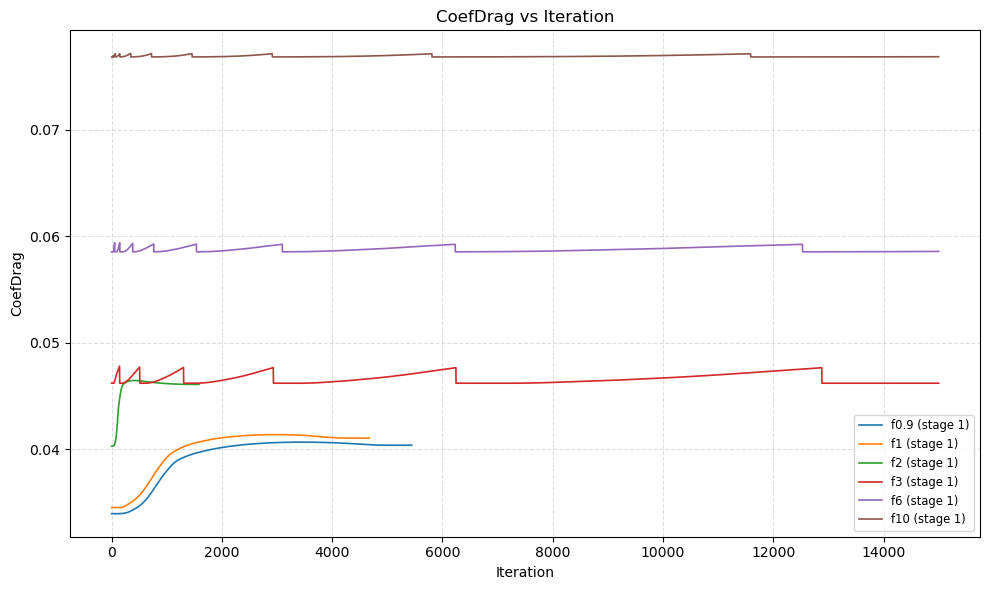

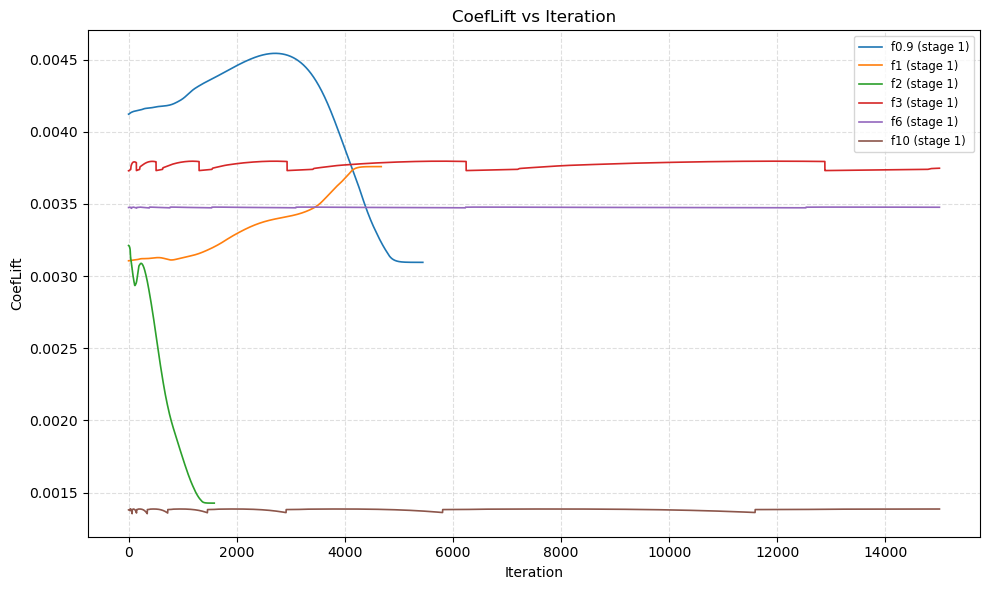

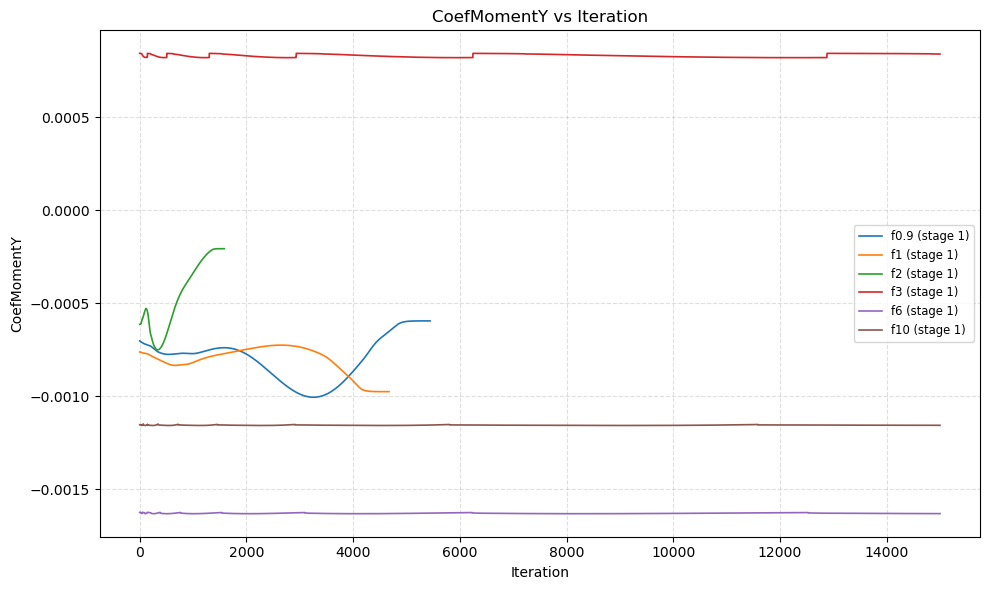

aoa_0.022_m_1.386


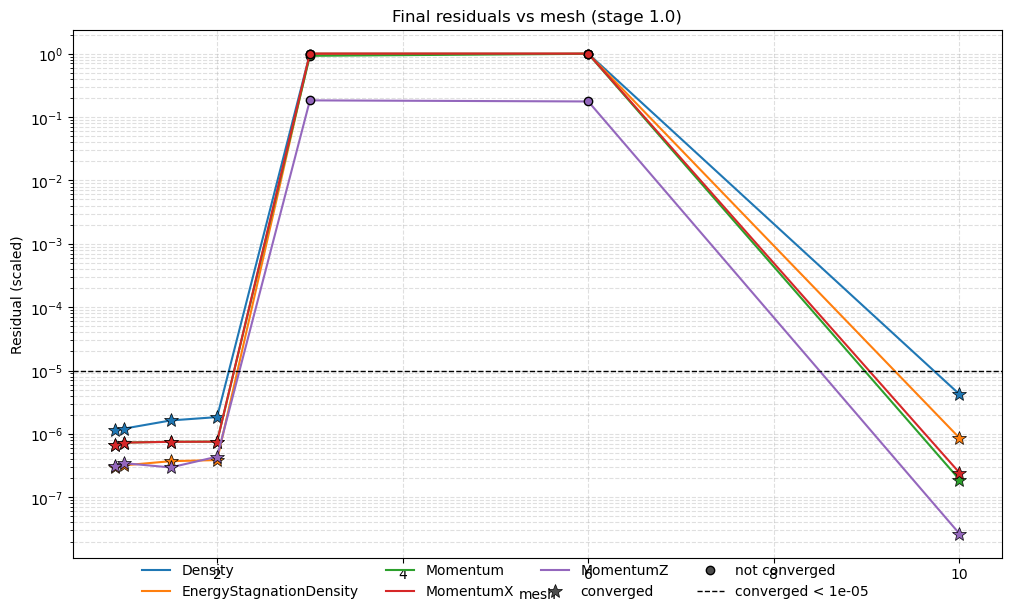

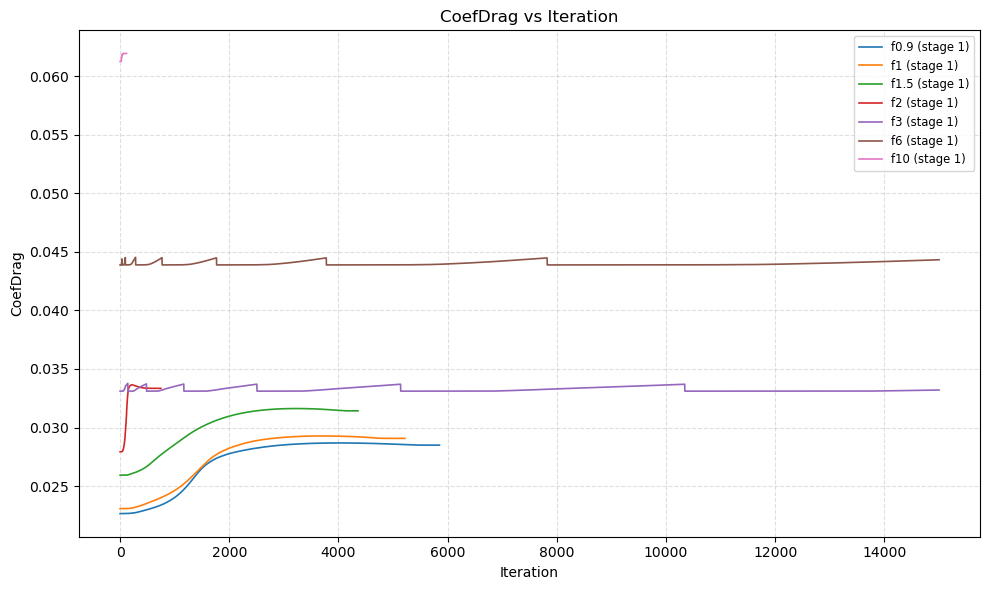

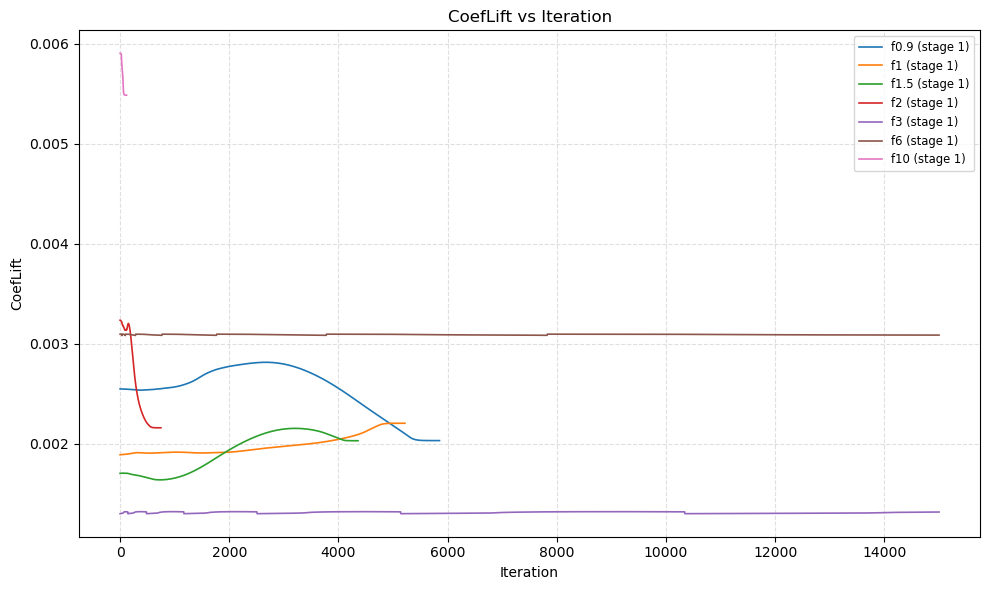

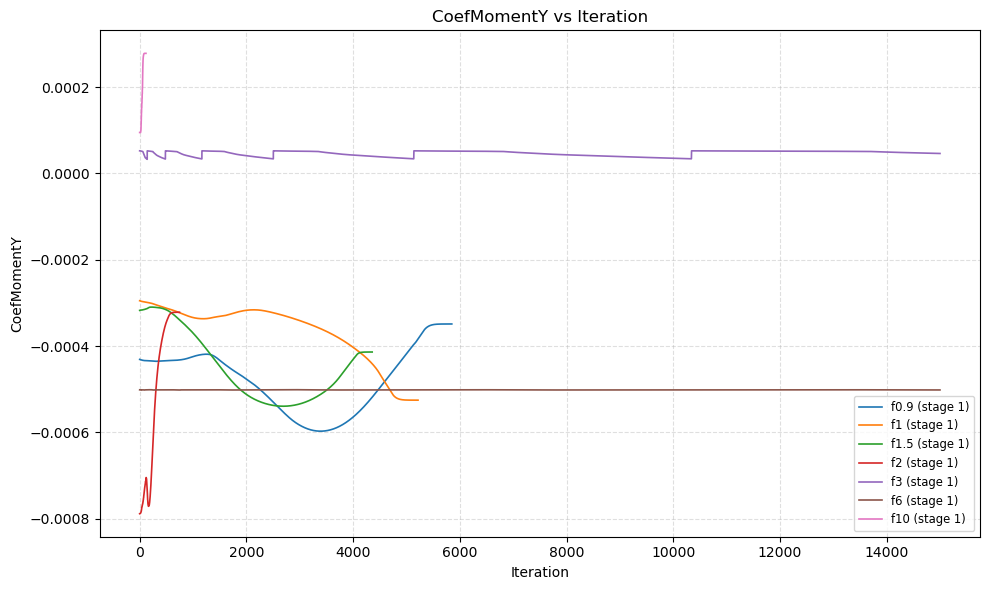

aoa_3.303_m_0.541


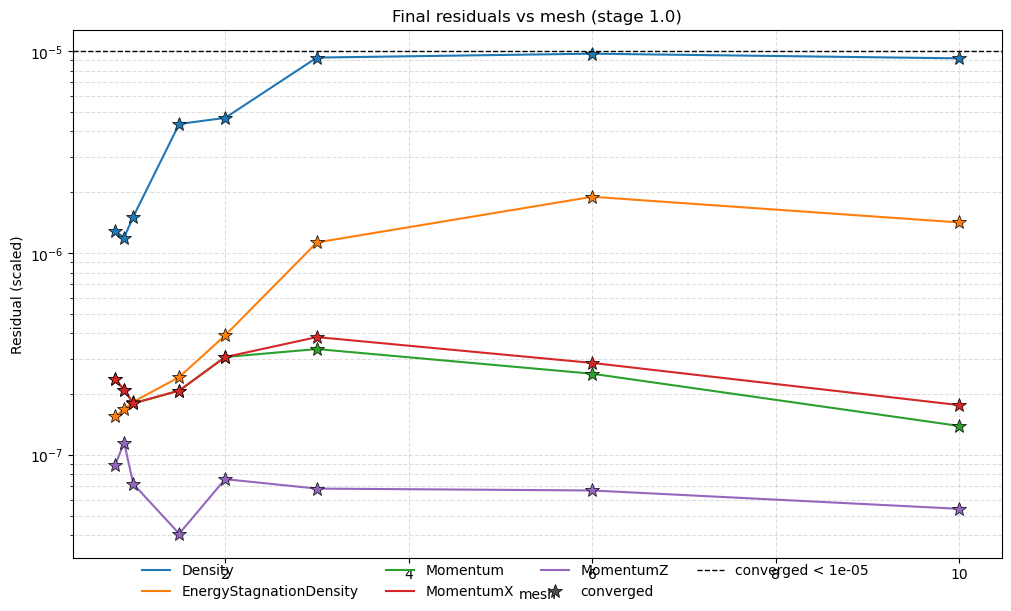

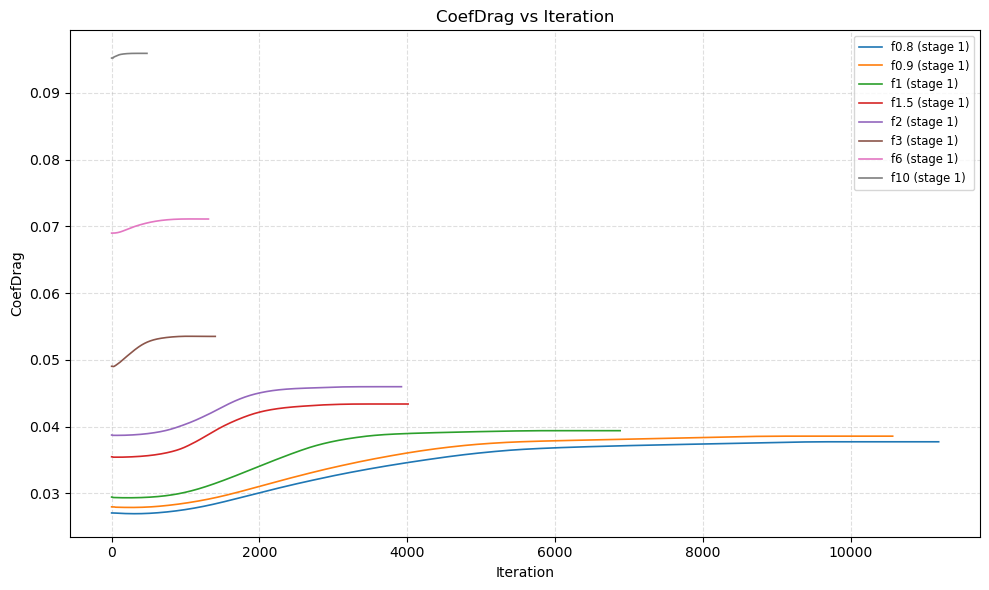

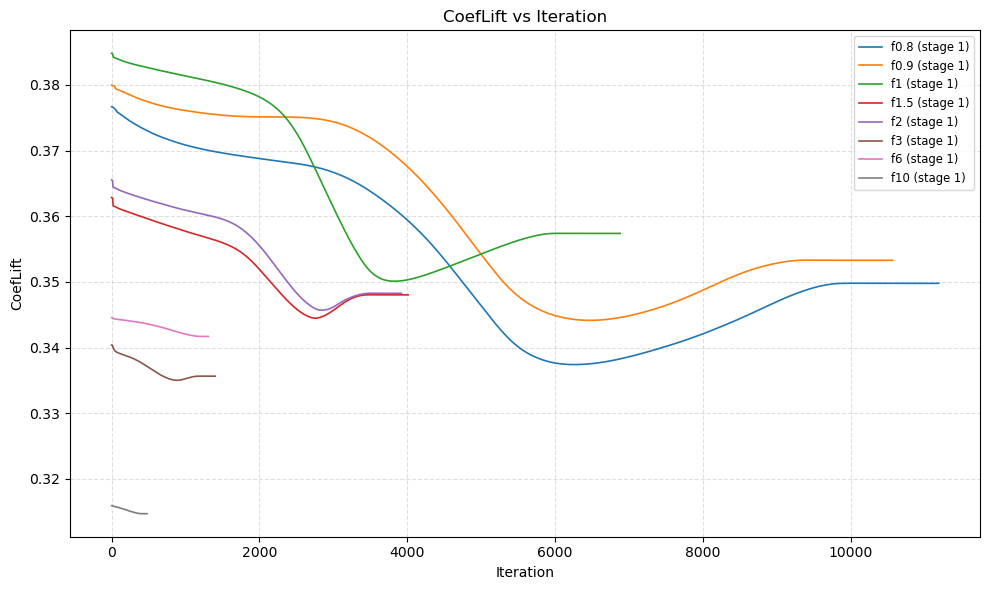

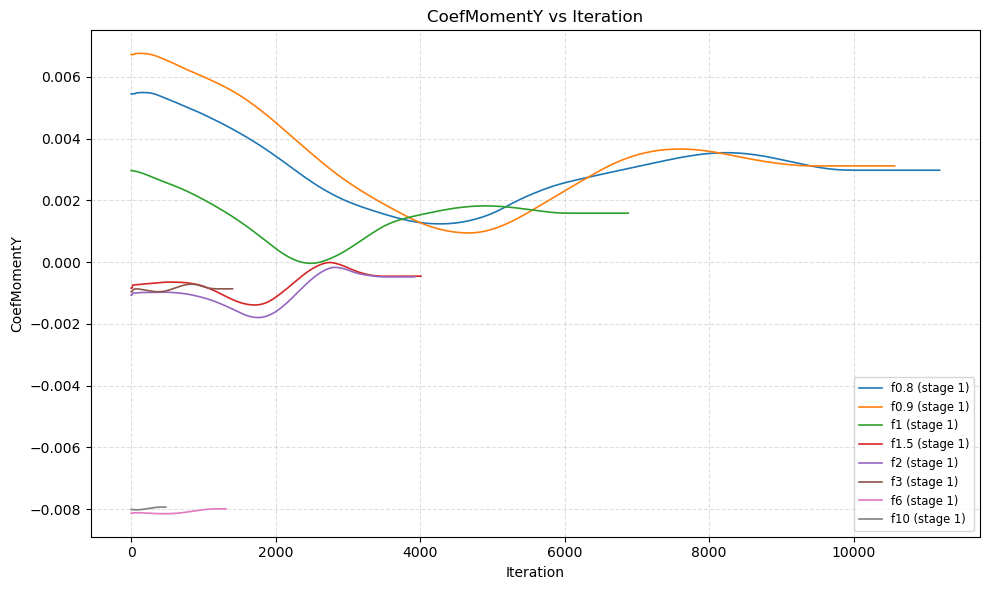

In [10]:
for folder, db_i in databases.items():
    print(folder)
    db_i.residuals.plot_all_final_residuals(
        save_dir=None,
        mode='scaled',
        stage=[0, 1],
        only_finished=False,
        print_non_converged=False,
        activate_idx=True,
    )

    # cases_idx son posiciones globales de df_cases: se toman todas las que
    # haya, en vez de fijar un numero (el estudio crece al anadir mallas).
    db_i.sets.plot_wall_integrals(
        cases_idx=db_i.metadata['df_cases']['case_idx'].tolist(),
        stage=[1],
        var_metrics='all',
        band=False,
    )

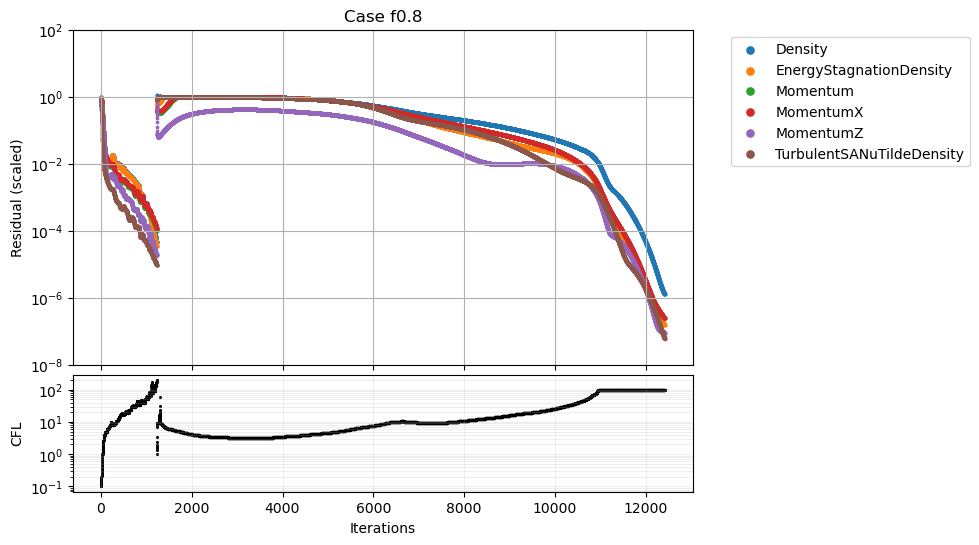

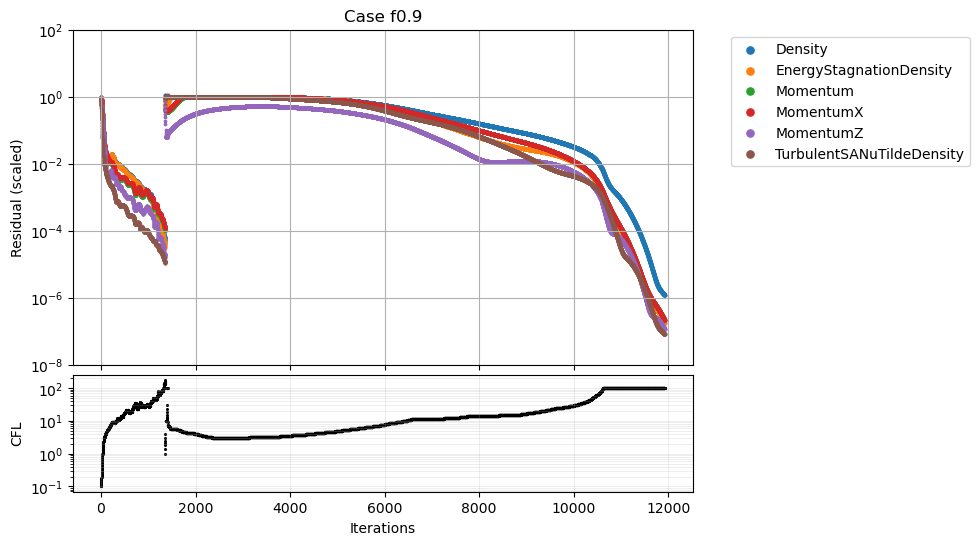

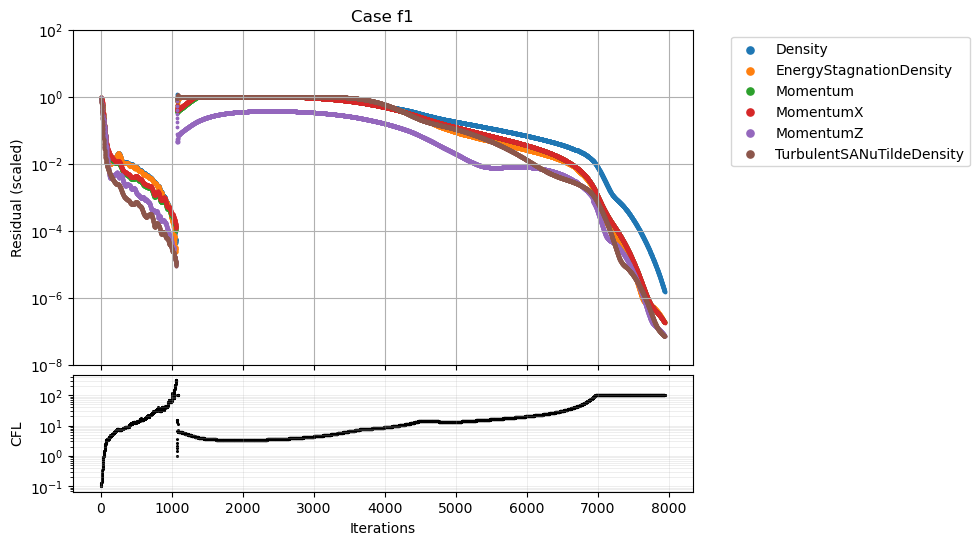

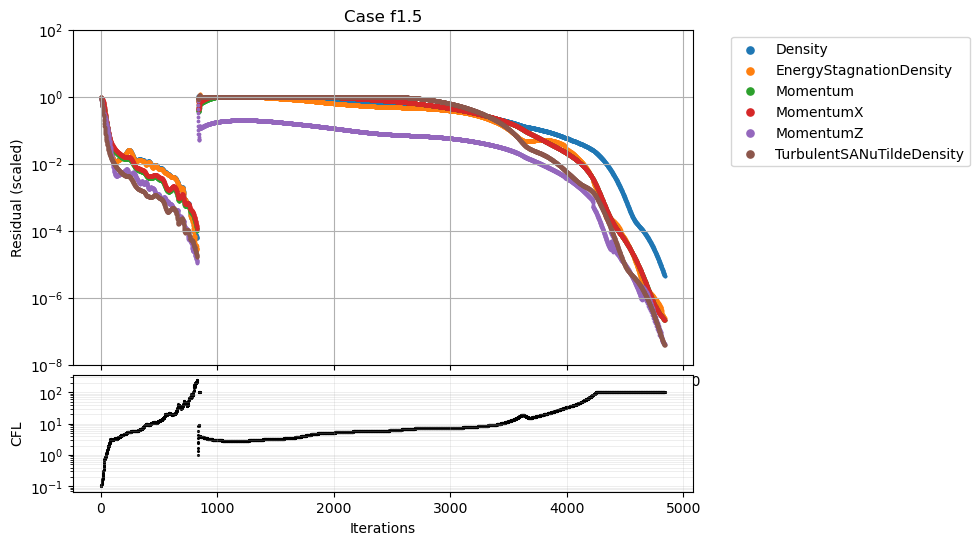

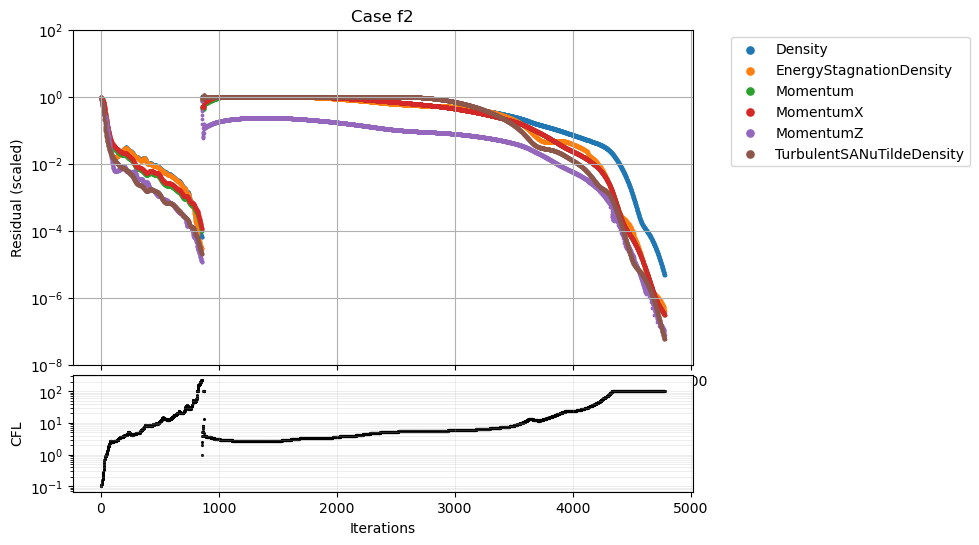

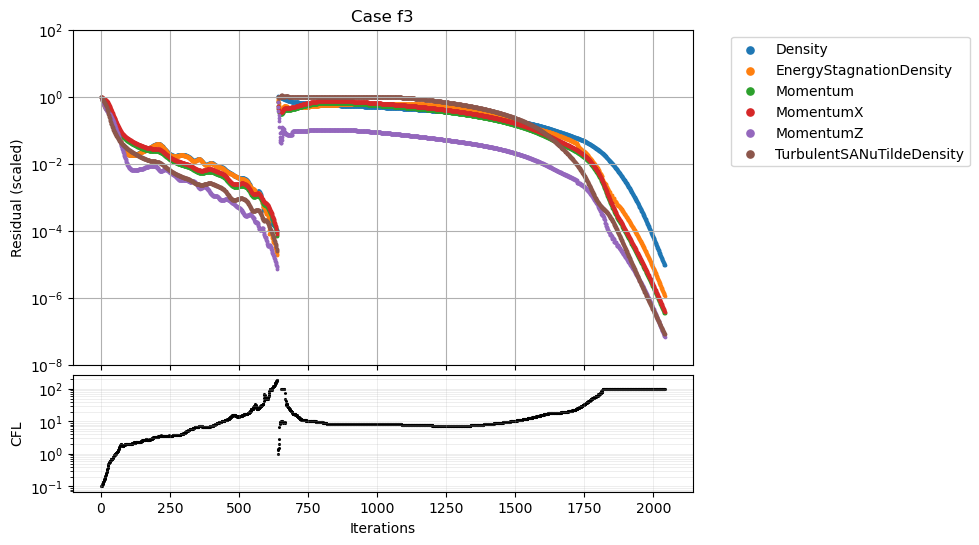

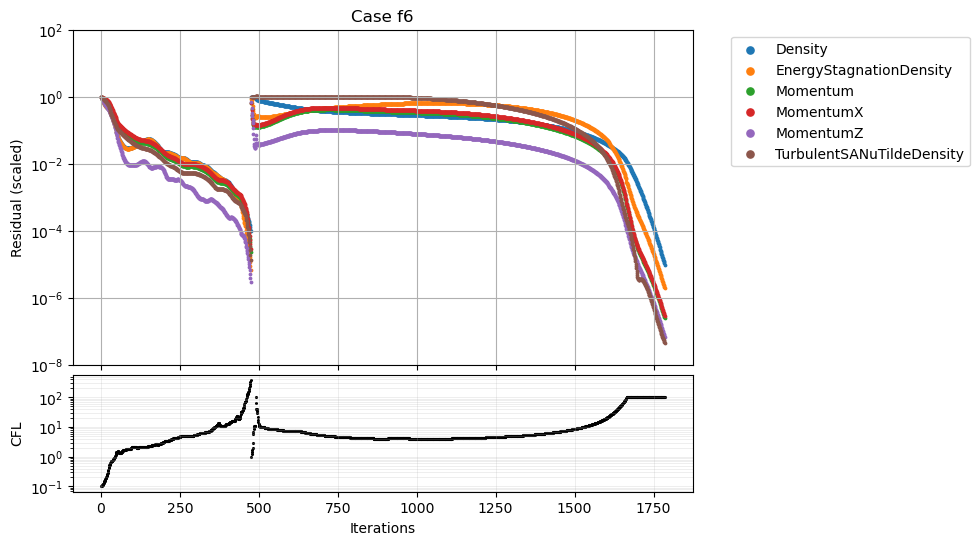

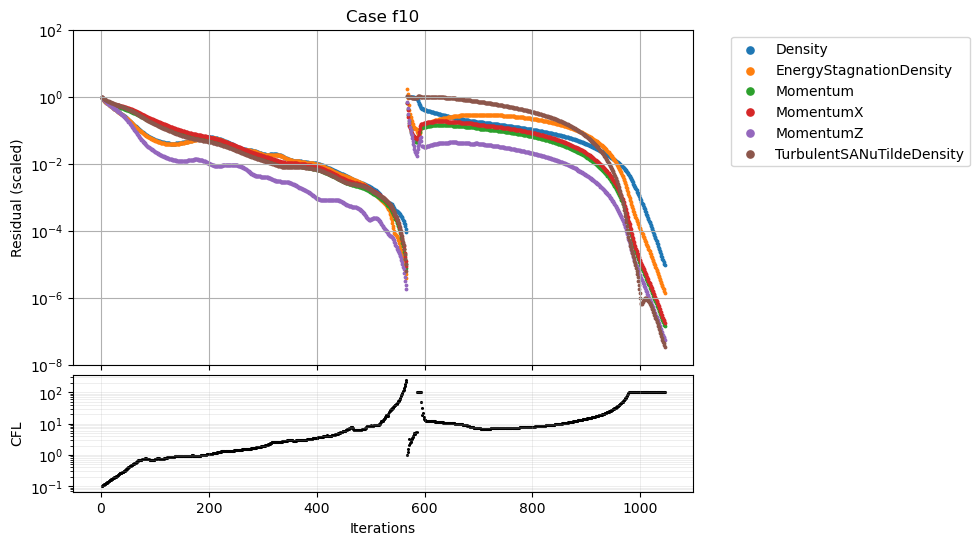

In [11]:
for case_idx in db.metadata['df_cases']['case_idx'].tolist():
    db.residuals.plot_residuals_from_case(
        case_idx=case_idx,
        stage='all',
        mode='scaled',
        save_dir=None,
    )

## 2. Lectura de la superficie: una malla por caso

`extract_inputs` guarda una geometria por caso (listas alineadas con `case_order`), no
una malla compartida. Un caso que aun no tenga un stage se extrae de los que tenga.

In [12]:
GROUP = 3          # CADGroupID de la pared
STAGE = 1          # stage refinado

for folder, db_i in databases.items():
    db_i.extract_inputs(id_groups=(GROUP,), cases_idx='all', vtu_type='surface')
    db_i.extract_outputs(
        stage=STAGE, id_groups=(GROUP,), cases_idx='all', vtu_type='surface',
        var_name_excluded=['GlobalNumber', 'CADGroupID'],
    )

grp = db.data_dict[f'CADGroup_{GROUP}']
print('casos           :', grp['case_order'])
print('puntos por caso :', [c.shape[0] for c in grp['Coord']])
print('malla por caso  :', grp['mesh_files'])
print('stages por caso :', grp['stages_available'])
print('saltados        :', db.reader.skipped_cases[f'CADGroup_{GROUP}'])

/home/m.jaraiz/repos/fellowship-of-the-ring/FotR/characters/readers/coda_single.py:908: UserWarning: CADGroup_3: case 'f0.8' has no stage 1 (has [0]); storing None for every variable.
  warnings.warn(
/home/m.jaraiz/repos/fellowship-of-the-ring/FotR/characters/readers/coda_single.py:908: UserWarning: CADGroup_3: case 'f1.5' has no stage 1 (has [0]); storing None for every variable.
  warnings.warn(
/home/m.jaraiz/repos/fellowship-of-the-ring/FotR/characters/readers/coda_single.py:908: UserWarning: CADGroup_3: case 'f0.8' has no stage 1 (has [0]); storing None for every variable.
  warnings.warn(


casos           : ['f0.8', 'f0.9', 'f1', 'f1.5', 'f2', 'f3', 'f6', 'f10']
puntos por caso : [7769, 7070, 6499, 4698, 3732, 2698, 1549, 1029]
malla por caso  : ['mesh_f22_v8_f0.8.msh', 'mesh_f22_v8_f0.9.msh', 'mesh_f22_v8_f1.0.msh', 'mesh_f22_v8_f1.5.msh', 'mesh_f22_v8_f2.0.msh', 'mesh_f22_v8_f3.0.msh', 'mesh_f22_v8_f6.0.msh', 'mesh_f22_v8_f10.0.msh']
stages por caso : [[0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]
saltados        : []


> **Ojo con esto.** En este dataset el parche de pared **satura**: `f0.8`, `f0.9`, `f1`
> y `f2` dan el mismo numero de celdas de superficie. El refinamiento global si cambia
> (el volumen), pero un `h` deducido del recuento de celdas *de superficie* daria
> `r = 1` para esas mallas y el GCI seria indefinido.
>
> Por eso abajo se usa **`h` = factor de malla** (la design var `mesh`), que es la
> magnitud que de verdad se refina.

## 3. Algebra de variables por caso y tendencia entre mallas

`compute_var` evalua una formula sobre los arrays de cada caso (sin `eval`), con las
design vars disponibles como escalares. `reduce_cases` colapsa cada malla a un numero,
que es lo unico comparable entre mallas que no comparten puntos.

In [13]:
import pandas as pd

CP = 'BoundaryValues_CoefPressure'

for db_i in databases.values():
    db_i.sets.compute_var('cp_abs', f'abs({CP})', stage=STAGE,
                          id_group=str(GROUP), overwrite=True)

trend = db.sets.reduce_cases(
    [CP, 'cp_abs'], stage=STAGE, id_group=str(GROUP), how='rms',
)
trend[['case', 'mesh', 'n_points', 'stages_available', CP, 'cp_abs']]

,case,mesh,n_points,stages_available,BoundaryValues_CoefPressure,cp_abs
0,f0.8,0.8,7769,"[0, 1]",0.289911,0.289911
1,f0.9,0.9,7070,"[0, 1]",0.292310,0.292310
2,f1,1.0,6499,"[0, 1]",0.293610,0.293610
3,f1.5,1.5,4698,"[0, 1]",0.286606,0.286606
4,f2,2.0,3732,"[0, 1]",0.283884,0.283884
5,f3,3.0,2698,"[0, 1]",0.276165,0.276165
6,f6,6.0,1549,"[0, 1]",0.268527,0.268527
7,f10,10.0,1029,"[0, 1]",0.246505,0.246505


In [14]:
# Un valor por caso y por reduccion, para ver la forma de la tendencia.
stats_table = db.stats.compute_stats(
    id_group=str(GROUP), stage=STAGE, variables=[CP],
    reductions=('mean', 'rms', 'min', 'max'),
)
stats_table[['case', 'mesh', 'n_points',
             f'{CP}_mean', f'{CP}_rms', f'{CP}_min', f'{CP}_max']]

,case,mesh,n_points,BoundaryValues_CoefPressure_mean,BoundaryValues_CoefPressure_rms,BoundaryValues_CoefPressure_min,BoundaryValues_CoefPressure_max
0,f0.8,0.8,7769,-0.105161,0.289911,-2.592619,2.068603
1,f0.9,0.9,7070,-0.104846,0.292310,-2.127065,2.349031
2,f1,1.0,6499,-0.106014,0.293610,-2.096302,2.361203
3,f1.5,1.5,4698,-0.104640,0.286606,-2.640479,1.824161
4,f2,2.0,3732,-0.103621,0.283884,-2.598626,1.542649
5,f3,3.0,2698,-0.101726,0.276165,-2.361312,2.134378
6,f6,6.0,1549,-0.098577,0.268527,-2.026185,1.794578
7,f10,10.0,1029,-0.099116,0.246505,-1.409755,1.287585


## 4. GCI sobre los coeficientes integrales

Es el objetivo clasico de un estudio de convergencia: una magnitud integral por malla.
`get_df_metrics` la saca de los monitores del solver, sin tocar geometria.

In [15]:
VARS = ['CoefLift', 'CoefDrag', 'CoefMomentY']

post = {}
for folder, db_i in databases.items():
    table = db_i.residuals.get_df_metrics(
        var_metrics=VARS, iter_var=1000, save=False,
    )
    post[folder] = table.rename(columns={'folder': 'case'})

post[folders[0]][['case', 'mesh'] + [f'{v}_mean_stage{STAGE}' for v in VARS]]

,case,mesh,CoefLift_mean_stage1,CoefDrag_mean_stage1,CoefMomentY_mean_stage1
0,f0.8,0.8,NaN,NaN,NaN
1,f0.9,0.9,0.003164,0.040403,-0.000622
2,f1,1.0,0.003702,0.041088,-0.000936
3,f1.5,1.5,NaN,NaN,NaN
4,f2,2.0,0.001722,0.046171,-0.000327
5,f3,3.0,0.003738,0.046198,0.000841
6,f6,6.0,0.003477,0.058565,-0.001631
7,f10,10.0,0.001385,0.076855,-0.001156


In [16]:
gci = {}
for folder, table in post.items():
    for var in VARS:
        col = f'{var}_mean_stage{STAGE}'
        clean = table.dropna(subset=[col])
        if len(clean) < 3:
            print(f'{folder} / {var}: solo {len(clean)} mallas, se omite')
            continue
        # h = factor de malla: es lo que de verdad se refina aqui.
        gci[(folder, var)] = databases[folder].stats.richardson(
            clean, col, h_col='mesh',
        )

summary = pd.concat(
    [g.assign(root=root, var=var) for (root, var), g in gci.items()],
    ignore_index=True,
)
summary[['root', 'var', 'fine', 'medium', 'coarse', 'r21', 'p',
         'f_extrapolated', 'GCI_21', 'converged']]

,root,var,fine,medium,coarse,r21,p,f_extrapolated,GCI_21,converged
0,aoa_0.022_m_1.071,CoefLift,f0.9,f1,f2,1.111111,NaN,NaN,NaN,False
1,aoa_0.022_m_1.071,CoefLift,f1,f2,f3,2.000000,0.032905,0.089566,28.989433,True
2,aoa_0.022_m_1.071,CoefLift,f2,f3,f6,1.500000,17.338640,0.001720,0.001297,True
3,aoa_0.022_m_1.071,CoefLift,f3,f6,f10,2.000000,4.204585,0.003753,0.005013,True
4,aoa_0.022_m_1.071,CoefDrag,f0.9,f1,f2,1.111111,NaN,NaN,NaN,False
5,aoa_0.022_m_1.071,CoefDrag,f1,f2,f3,2.000000,5.212573,0.040947,0.004286,True
6,aoa_0.022_m_1.071,CoefDrag,f2,f3,f6,1.500000,8.766498,0.046170,0.000022,True
7,aoa_0.022_m_1.071,CoefDrag,f3,f6,f10,2.000000,1.177994,0.036404,0.265016,True
8,aoa_0.022_m_1.071,CoefMomentY,f0.9,f1,f2,1.111111,NaN,NaN,NaN,False
9,aoa_0.022_m_1.071,CoefMomentY,f1,f2,f3,2.000000,2.284173,-0.001093,0.210122,True


### Lectura de la tabla

* `p` es el **orden observado**. Vale `NaN` cuando la tripleta esta mal planteada: dos
  mallas con el mismo valor, mallas que no refinan (`r = 1`) o diferencias que cambian
  de signo (convergencia oscilatoria). Es deliberado: un `p` no convergido redondeado a
  un numero es como un estudio acaba afirmando un orden que nunca tuvo.
* `GCI_21` es la banda de incertidumbre **relativa** de la malla fina de cada tripleta.
* `r21 = 1.125` entre `f0.8` y `f0.9` es un refinamiento muy pequeno (Roache recomienda
  `r >= 1.3`), asi que esas tripletas son ruidosas. La de `f1 / f2 / f5` (`r = 2` y
  `2.5`) es la fiable.

In [17]:
# La tripleta mas fiable de cada raiz y variable: la de mayor r21 entre las convergidas.
best = (
    summary[summary['converged']]
    .sort_values('r21', ascending=False)
    .groupby(['root', 'var'], as_index=False)
    .first()
)
best[['root', 'var', 'fine', 'medium', 'coarse', 'r21', 'p',
      'f1', 'f_extrapolated', 'GCI_21']]

,root,var,fine,medium,coarse,r21,p,f1,f_extrapolated,GCI_21
0,aoa_0.022_m_1.071,CoefDrag,f1,f2,f3,2.0,5.212573,0.041088,0.040947,0.004286
1,aoa_0.022_m_1.071,CoefLift,f1,f2,f3,2.0,0.032905,0.003702,0.089566,28.989433
2,aoa_0.022_m_1.071,CoefMomentY,f1,f2,f3,2.0,2.284173,-0.000936,-0.001093,0.210122
3,aoa_0.022_m_1.386,CoefDrag,f3,f6,f10,2.0,1.292414,0.033166,0.025515,0.288374
4,aoa_0.022_m_1.386,CoefLift,f3,f6,f10,2.0,1.135559,0.001313,-0.000169,1.410637
5,aoa_0.022_m_1.386,CoefMomentY,f3,f6,f10,2.0,0.427876,0.000048,0.001639,41.481633
6,aoa_3.303_m_0.541,CoefDrag,f3,f6,f10,2.0,1.107766,0.053302,0.038099,0.356520
7,aoa_3.303_m_0.541,CoefLift,f3,f6,f10,2.0,2.541235,0.335783,0.334349,0.005337
8,aoa_3.303_m_0.541,CoefMomentY,f3,f6,f10,2.0,4.995883,-0.000825,-0.000591,0.355257


## 5. Curvas de convergencia

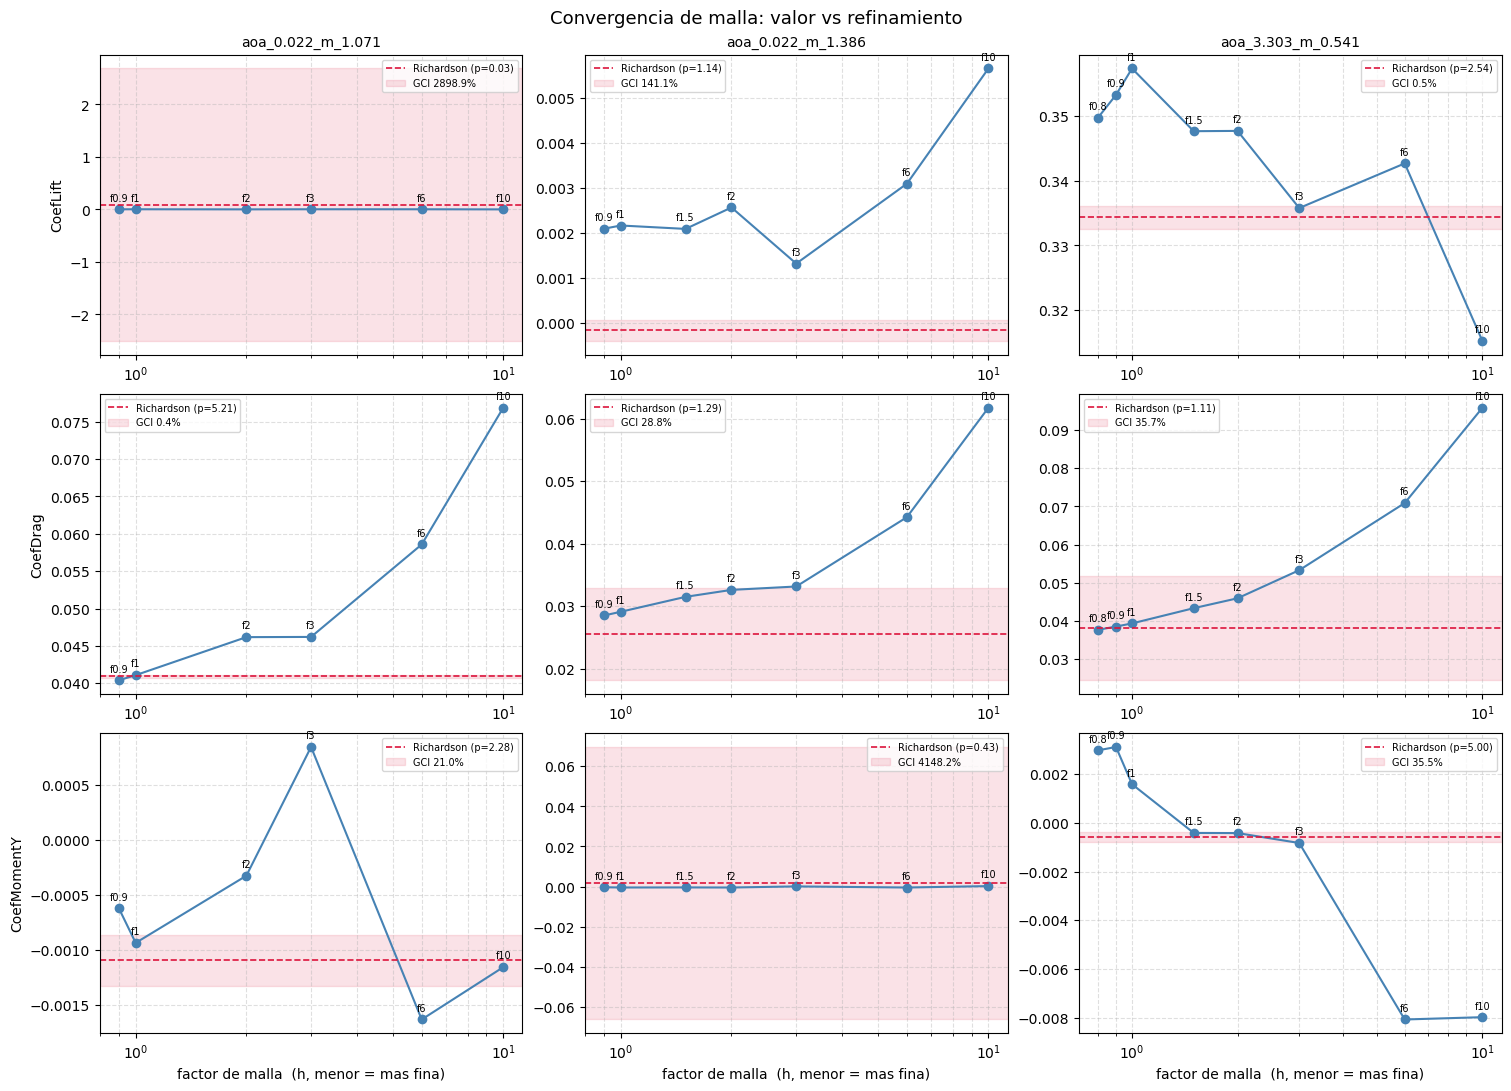

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(VARS), len(folders),
                         figsize=(5 * len(folders), 3.6 * len(VARS)),
                         squeeze=False, constrained_layout=True)

for j, folder in enumerate(folders):
    table = post[folder]
    for i, var in enumerate(VARS):
        ax = axes[i][j]
        col = f'{var}_mean_stage{STAGE}'
        clean = table.dropna(subset=[col]).sort_values('mesh')
        ax.plot(clean['mesh'], clean[col], 'o-', color='steelblue')
        for _, row in clean.iterrows():
            ax.annotate(str(row['case']), (row['mesh'], row[col]),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=7)

        rows = best[(best['root'] == folder) & (best['var'] == var)]
        if len(rows):
            row = rows.iloc[0]
            ax.axhline(row['f_extrapolated'], color='crimson', ls='--', lw=1.2,
                       label=f"Richardson (p={row['p']:.2f})")
            band = abs(row['f_extrapolated']) * row['GCI_21']
            ax.axhspan(row['f_extrapolated'] - band,
                       row['f_extrapolated'] + band,
                       color='crimson', alpha=0.12,
                       label=f"GCI {row['GCI_21'] * 100:.1f}%")
            ax.legend(fontsize=7, loc='best')

        ax.set_xscale('log')
        ax.grid(True, which='both', ls='--', alpha=0.4)
        if i == 0:
            ax.set_title(folder, fontsize=10)
        if j == 0:
            ax.set_ylabel(var)
        if i == len(VARS) - 1:
            ax.set_xlabel('factor de malla  (h, menor = mas fina)')

fig.suptitle('Convergencia de malla: valor vs refinamiento', fontsize=13)
plt.show()

## 6. GCI sobre un campo de superficie

Mismo procedimiento, pero partiendo de una reduccion del campo en lugar de una integral
del solver. Sirve para ver si la conclusion depende de la magnitud elegida.

In [19]:
field_gci = []
for folder, db_i in databases.items():
    table = db_i.sets.reduce_cases(
        CP, stage=STAGE, id_group=str(GROUP), how='rms', dropna=True,
    )
    if len(table) < 3:
        continue
    field_gci.append(
        db_i.stats.richardson(table, CP, h_col='mesh').assign(root=folder)
    )

field_gci = pd.concat(field_gci, ignore_index=True)
field_gci[['root', 'fine', 'medium', 'coarse', 'r21', 'p',
           'f1', 'f_extrapolated', 'GCI_21', 'converged']]

,root,fine,medium,coarse,r21,p,f1,f_extrapolated,GCI_21,converged
0,aoa_0.022_m_1.071,f0.9,f1,f2,1.111111,NaN,0.204407,NaN,NaN,False
1,aoa_0.022_m_1.071,f1,f2,f3,2.000000,2.984509,0.204554,0.203907,0.003949,True
2,aoa_0.022_m_1.071,f2,f3,f6,1.500000,3.382953,0.209022,0.209116,0.000561,True
3,aoa_0.022_m_1.071,f3,f6,f10,2.000000,2.213980,0.208747,0.208056,0.004137,True
4,aoa_0.022_m_1.386,f0.9,f1,f1.5,1.111111,NaN,0.118669,NaN,NaN,False
5,aoa_0.022_m_1.386,f1,f1.5,f2,1.500000,0.086103,0.119173,-0.032012,1.585770,True
6,aoa_0.022_m_1.386,f1.5,f2,f3,1.333333,2.678887,0.124545,0.121392,0.031648,True
7,aoa_0.022_m_1.386,f2,f3,f6,1.500000,2.482779,0.128206,0.129429,0.011925,True
8,aoa_0.022_m_1.386,f3,f6,f10,2.000000,2.435145,0.126082,0.123757,0.023053,True
9,aoa_3.303_m_0.541,f0.8,f0.9,f1,1.125000,4.024032,0.289911,0.285956,0.017053,True


## 7. Exportacion

El tensor largo concatena un bloque por caso (alturas distintas, mismas columnas), y
`case_offsets` permite recortar cualquier caso. El `.npy` escribe una clave por caso,
que es lo que hace que `FRODO(format='NUMPY')` pueda releerlo.

In [20]:
jset = db.sets.create_jset(stage=STAGE, id_group=str(GROUP), variables=[CP])
print('tensor        :', tuple(jset['tensor'].shape))
print('case_offsets  :', jset['case_offsets'].tolist())
print('case_order    :', jset['case_order'])
print('columnas      :', db.df_data.columns.tolist())
print('suma de puntos:', sum(c.shape[0] for c in grp['Coord']))
db.df_data.head()

tensor        : (35044, 7)
case_offsets  : [0, 7769, 14839, 21338, 26036, 29768, 32466, 34015, 35044]
case_order    : ['f0.8', 'f0.9', 'f1', 'f1.5', 'f2', 'f3', 'f6', 'f10']
columnas      : ['case', 'x', 'y', 'z', 'aoa', 'mach', 'mesh', 'BoundaryValues_CoefPressure']
suma de puntos: 35044


,case,x,y,z,aoa,mach,mesh,BoundaryValues_CoefPressure
0,f0.8,-0.171351,0.5,0.000004,3.303404,0.541381,0.8,2.068603
1,f0.8,-0.171320,0.5,0.000037,3.303404,0.541381,0.8,-2.592619
2,f0.8,-0.171294,0.5,-0.000027,3.303404,0.541381,0.8,1.397708
3,f0.8,-0.171233,0.5,0.000056,3.303404,0.541381,0.8,-2.204467
4,f0.8,-0.171207,0.5,-0.000043,3.303404,0.541381,0.8,1.137955


In [21]:
import tempfile

out_dir = tempfile.mkdtemp(prefix='gci_export_')
npy_path = db.sets.save_to_npy(os.path.join(out_dir, 'gci'),
                               stage=STAGE, id_group=str(GROUP))
h5_path = db.sets.save_to_h5(os.path.join(out_dir, 'gci'),
                             stage=STAGE, id_group=str(GROUP))
print('npy:', npy_path)
print('h5 :', h5_path)

# Round-trip: el .npy vuelve a entrar en FRODO como formato NUMPY.
back = FRODO(root_dir=out_dir, format='NUMPY',
             file=os.path.basename(npy_path), initial_parse=True)
print('grupos releidos:', sorted(back.reader.group_index))

npy: /tmp/gci_export_vvno5c6r/gci.npy
h5 : /tmp/gci_export_vvno5c6r/gci.h5
grupos releidos: ['CADGroup_3__f0.8', 'CADGroup_3__f0.9', 'CADGroup_3__f1', 'CADGroup_3__f1.5', 'CADGroup_3__f10', 'CADGroup_3__f2', 'CADGroup_3__f3', 'CADGroup_3__f6']


/home/m.jaraiz/repos/fellowship-of-the-ring/FotR/characters/frodo.py:153: UserWarning: No Residuals class for format 'NUMPY'. Residuals methods will not be available.
  warnings.warn(
